In [1]:
from pathlib import Path
import sys
import numpy as np

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from IPython.display import Audio

In [2]:
from spectral_mixture_analysis.audio import load_mono_audio, match_length, mix_signals
from spectral_mixture_analysis.transforms import (
    amplitude_to_db,
    compute_representation,
    representation_to_db
)
from spectral_mixture_analysis.metrics import l2_error, relative_l2_error
from spectral_mixture_analysis.plotting import plot_spectrogram, plot_difference_map

In [3]:
audio_path_1 = PROJECT_ROOT / "data" / "samples" / "flute" / "Track1_flute.wav"
audio_path_2 = PROJECT_ROOT / "data" / "samples" / "bass" / "Track10_Bass.wav"
x, sr = load_mono_audio(audio_path_1, sr=22050)
y, _ = load_mono_audio(audio_path_2, sr=22050)

x, y = match_length(x, y, mode="truncate")
mix = x + y

In [4]:
from spectral_mixture_analysis.dataset import build_sample_index

samples_root = PROJECT_ROOT / "data" / "samples"
index_df = build_sample_index(samples_root)

index_df.head(12)

,instrument,track_id,path,filename
0,bass,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_Bass.wav
1,flute,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_flute.wav
2,piano,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_Acoustic_Grand_Piano.wav
3,trumpet,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_trumpet.wav
4,bass,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_Bass.wav
5,flute,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_flute.wav
6,piano,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_Acoustic_Grand_Piano.wav
7,trumpet,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_trumpet.wav
8,bass,3,/home/satan/git/spectrogram-analysis/data/samp...,Track3_Bass.wav
9,flute,3,/home/satan/git/spectrogram-analysis/data/samp...,Track3_flute.wav


In [5]:
from spectral_mixture_analysis.dataset import get_track_instrument_pairs, get_same_pair_across_tracks

pairs_track_1 = get_track_instrument_pairs(index_df, track_id=1)
pairs_bass_flute = get_same_pair_across_tracks(index_df, "bass", "flute")

In [6]:
print("Audio x")
display(Audio(x, rate=sr))

print("Audio y")
display(Audio(y, rate=sr))

print("Mixture x+y")
mix_listen = mix / (np.max(np.abs(mix)) + 1e-9)
display(Audio(mix_listen, rate=sr))

Audio x


Audio y


Mixture x+y


In [7]:
FMIN = 30.0
FMAX = 11000.0
BINS = 48
SCALE = "oct"

rep_x   = compute_representation(x,   sr, transform_type="nsgt", fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE)
rep_y   = compute_representation(y,   sr, transform_type="nsgt", fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE)
rep_mix = compute_representation(mix, sr, transform_type="nsgt", fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE)
rep_sum = rep_x + rep_y

# Approximate hop length for time-axis display (signal samples / number of time frames)
hop_length_nsgt = len(x) // rep_x.shape[1]

mix_db = amplitude_to_db(rep_mix)
sum_db = amplitude_to_db(rep_sum)
diff   = rep_mix - rep_sum

print(f"NSGT output shape: {rep_x.shape}  (n_freqs x n_frames)")
print(f"Approximate hop length for display: {hop_length_nsgt} samples")

NSGT output shape: (410, 1925)  (n_freqs x n_frames)
Approximate hop length for display: 70 samples


/home/satan/git/variational-timbre/nsgt3/fft.py:111: UserWarning: nsgt.fft falling back to numpy.fft
  warn("nsgt.fft falling back to numpy.fft")
/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30,44.94
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))


In [8]:
overlap_2 = np.sum(np.minimum(rep_x, rep_y)) / np.sum(rep_x + rep_y)
overlap_2_db = representation_to_db(np.array([overlap_2]), ref=1.0, scale="amplitude")[0]
print(f"Overlap (rep): {overlap_2:.4f} ({overlap_2_db:.2f} dB)")

Overlap (rep): 0.0146 (-36.74 dB)


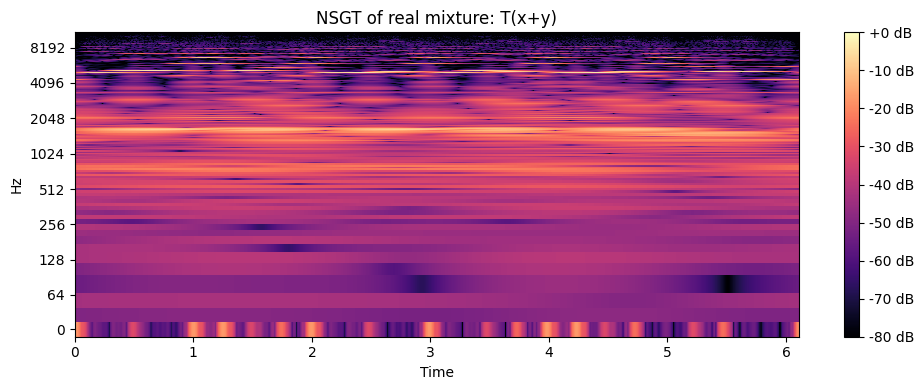

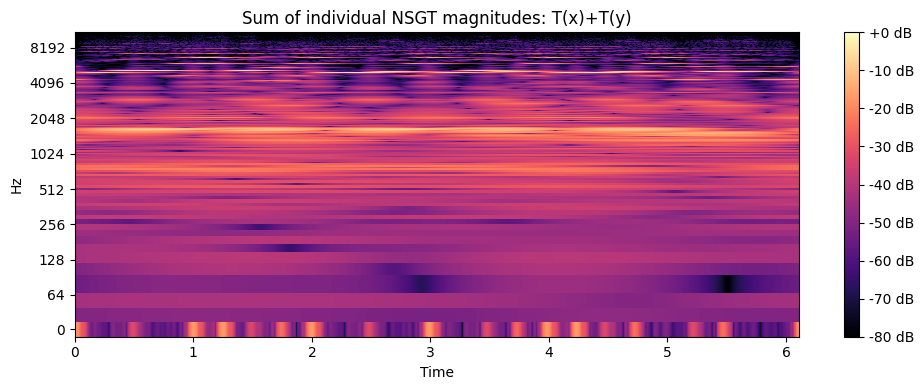

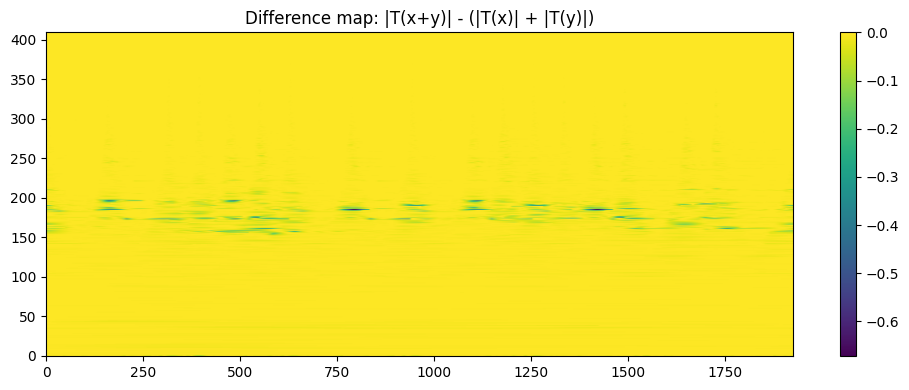

In [9]:
plot_spectrogram(mix_db, sr=sr, hop_length=hop_length_nsgt, title="NSGT of real mixture: T(x+y)")
plot_spectrogram(sum_db, sr=sr, hop_length=hop_length_nsgt, title="Sum of individual NSGT magnitudes: T(x)+T(y)")
plot_difference_map(diff, title="Difference map: |T(x+y)| - (|T(x)| + |T(y)|)")

In [10]:
from spectral_mixture_analysis.analysis import evaluate_mixture_linearity

metrics = evaluate_mixture_linearity(
    x, y, sr=sr,
    transform_type="nsgt",
    fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE
)

print(metrics)

{'l2': 13.433276176452637, 'relative_l2': 0.017838425934314728, 'mae': 0.003455287776887417, 'overlap': 0.014554562047123909}


In [11]:
from spectral_mixture_analysis.analysis import evaluate_dataset_pairs

pairs = [
    (PROJECT_ROOT / "data" / "raw" / "audio01_bass.wav",
     PROJECT_ROOT / "data" / "raw" / "audio02_vocal.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio03_bass.wav",
     PROJECT_ROOT / "data" / "raw" / "audio04_flute.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio05_guitar_aco.wav",
     PROJECT_ROOT / "data" / "raw" / "audio06_guitar_ele.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio07_keyboard_aco.wav",
     PROJECT_ROOT / "data" / "raw" / "audio08_keyboard_ele.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio09_keyboard_ele.wav",
     PROJECT_ROOT / "data" / "raw" / "audio10_organ_ele.wav"),

    (PROJECT_ROOT / "data" / "samples" / "flute" / "Track1_flute.wav",
     PROJECT_ROOT / "data" / "samples" / "bass" / "Track10_Bass.wav")
]

df = evaluate_dataset_pairs(
    pairs, transform_type="nsgt",
    fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE
)

df

/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30,44.94,45.60,46.26,46.93,47.62,48.31,49.01,49.72,50.45,51.18,51.92,52.68,53.44,54.22,55.01,55.81,56.62,57.45,58.28,59.13,59.99,60.86,61.75,62.64,63.55,64.48,65.42,66.37,67.33,68.31
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))


,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,audio01_bass,audio02_vocal,nsgt,55.452888,0.118713,0.004898,0.028983
1,audio03_bass,audio04_flute,nsgt,12.236917,0.019357,0.004464,0.033842
2,audio05_guitar_aco,audio06_guitar_ele,nsgt,13.580446,0.037734,0.001957,0.023920
3,audio07_keyboard_aco,audio08_keyboard_ele,nsgt,34.887341,0.093056,0.009634,0.112056
4,audio09_keyboard_ele,audio10_organ_ele,nsgt,35.297592,0.046528,0.008438,0.058073
5,Track1_flute,Track10_Bass,nsgt,13.433276,0.017838,0.003455,0.014555


In [12]:
pairs_bass_flute = get_same_pair_across_tracks(index_df, "bass", "flute")
df_bass_flute = evaluate_dataset_pairs(
    pairs_bass_flute, transform_type="nsgt",
    fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE
)

df_bass_flute

/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30,44.94
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))
/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))


,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,Track1_Bass,Track1_flute,nsgt,13.484826,0.018190,0.003707,0.016455
1,Track2_Bass,Track2_flute,nsgt,4.747517,0.006028,0.001842,0.007255
2,Track3_Bass,Track3_flute,nsgt,2.616186,0.003791,0.001293,0.006364
3,Track4_Bass,Track4_flute,nsgt,5.243929,0.007458,0.002252,0.011578
4,Track5_Bass,Track5_flute,nsgt,5.530346,0.007031,0.002120,0.009850
5,Track6_Bass,Track6_flute,nsgt,8.048988,0.009987,0.002847,0.011693
6,Track7_Bass,Track7_flute,nsgt,5.800758,0.006278,0.002228,0.009240
7,Track8_Bass,Track8_flute,nsgt,9.874068,0.011872,0.002508,0.010409
8,Track9_Bass,Track9_flute,nsgt,21.248201,0.031417,0.004156,0.028448
9,Track10_Bass,Track10_flute,nsgt,10.417994,0.011963,0.002952,0.012095


In [13]:
pairs_track_1 = get_track_instrument_pairs(index_df, track_id=1)
df_track_1 = evaluate_dataset_pairs(
    pairs_track_1, transform_type="nsgt",
    fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE
)

df_track_1

/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30,44.94
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))


,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,Track1_Bass,Track1_flute,nsgt,13.484826,0.018190,0.003707,0.016455
1,Track1_Bass,Track1_Acoustic_Grand_Piano,nsgt,77.302284,0.112807,0.029946,0.105136
2,Track1_Bass,Track1_trumpet,nsgt,15.488491,0.021959,0.003630,0.013187
3,Track1_flute,Track1_Acoustic_Grand_Piano,nsgt,76.224121,0.102022,0.011794,0.066205
4,Track1_flute,Track1_trumpet,nsgt,163.428223,0.217715,0.023950,0.117962
5,Track1_Acoustic_Grand_Piano,Track1_trumpet,nsgt,55.457966,0.078244,0.014114,0.062975


In [14]:
pairs_piano_trumpet = get_same_pair_across_tracks(index_df, "piano", "trumpet")
df_piano_trumpet = evaluate_dataset_pairs(
    pairs_piano_trumpet, transform_type="nsgt",
    fmin=FMIN, fmax=FMAX, bins=BINS, scale=SCALE
)

df_piano_trumpet

/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30,44.94
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))


,file_x,file_y,transform_type,l2,relative_l2,mae,overlap
0,Track1_Acoustic_Grand_Piano,Track1_trumpet,nsgt,55.457966,0.078244,0.014114,0.062975
1,Track2_Acoustic_Grand_Piano,Track2_trumpet,nsgt,51.107323,0.069931,0.008825,0.038070
2,Track3_Acoustic_Grand_Piano,Track3_trumpet,nsgt,22.032610,0.030806,0.004599,0.022207
3,Track4_Acoustic_Grand_Piano,Track4_trumpet,nsgt,18.224487,0.028304,0.003510,0.019150
4,Track5_Acoustic_Grand_Piano,Track5_trumpet,nsgt,22.670530,0.033024,0.004585,0.024507
5,Track6_Acoustic_Grand_Piano,Track6_trumpet,nsgt,30.804661,0.042940,0.006100,0.028134
6,Track7_Acoustic_Grand_Piano,Track7_trumpet,nsgt,35.157932,0.045857,0.008927,0.036318
7,Track8_Acoustic_Grand_Piano,Track8_trumpet,nsgt,55.281704,0.075125,0.010311,0.042658
8,Track9_Acoustic_Grand_Piano,Track9_trumpet,nsgt,36.691261,0.057099,0.005291,0.027710
9,Track10_Acoustic_Grand_Piano,Track10_trumpet,nsgt,45.811386,0.063153,0.010978,0.046152


In [15]:
print("Bass-Flute pairs:", df_bass_flute["relative_l2"].mean())
print("Piano-Trumpet pairs:", df_piano_trumpet["relative_l2"].mean())

Bass-Flute pairs: 0.010331819299608469
Piano-Trumpet pairs: 0.05665846262127161


In [16]:
import pandas as pd
from spectral_mixture_analysis.audio import load_mono_audio, match_length
from spectral_mixture_analysis.analysis import evaluate_mixture_linearity


results = []

for path_x, path_y in pairs:
    x, sr = load_mono_audio(path_x)
    y, _ = load_mono_audio(path_y)

    x, y = match_length(x, y, mode="truncate")

    metrics = evaluate_mixture_linearity(
        x=x,
        y=y,
        sr=sr,
        transform_type="nsgt",
        include_overlap=True,
        fmin=FMIN,
        fmax=FMAX,
        bins=BINS,
        scale=SCALE,
    )

    results.append({
        "file_x": path_x.name,
        "file_y": path_y.name,
        **metrics
    })

df = pd.DataFrame(results)
df

/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30,44.94,45.60,46.26,46.93,47.62,48.31,49.01,49.72,50.45,51.18,51.92,52.68,53.44,54.22,55.01,55.81,56.62,57.45,58.28,59.13,59.99,60.86,61.75,62.64,63.55,64.48,65.42,66.37,67.33,68.31
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))
/home/satan/git/variational-timbre/nsgt3/nsgfwin_sl.py:64: UserWarning: Q-factor too high for frequencies 30.00,30.44,30.88,31.33,31.78,32.25,32.71,33.19,33.67,34.16,34.66,35.16,35.67,36.19,36.72,37.25,37.80,38.34,38.90,39.47,40.04,40.62,41.21,41.81,42.42,43.04,43.66,44.30,44.94
  warn("Q-factor too high for frequencies %s"%",".join("%.2f"%fi for fi in f[q >= qneeded]))


,file_x,file_y,l2,relative_l2,mae,overlap
0,audio01_bass.wav,audio02_vocal.wav,55.452888,0.118713,0.004898,0.028983
1,audio03_bass.wav,audio04_flute.wav,12.236917,0.019357,0.004464,0.033842
2,audio05_guitar_aco.wav,audio06_guitar_ele.wav,13.580446,0.037734,0.001957,0.023920
3,audio07_keyboard_aco.wav,audio08_keyboard_ele.wav,34.887341,0.093056,0.009634,0.112056
4,audio09_keyboard_ele.wav,audio10_organ_ele.wav,35.297592,0.046528,0.008438,0.058073
5,Track1_flute.wav,Track10_Bass.wav,13.433276,0.017838,0.003455,0.014555


In [17]:
corr = df["overlap"].corr(df["relative_l2"])
print("Correlation (overlap vs relative_l2):", corr)

Correlation (overlap vs relative_l2): 0.4477760946827663


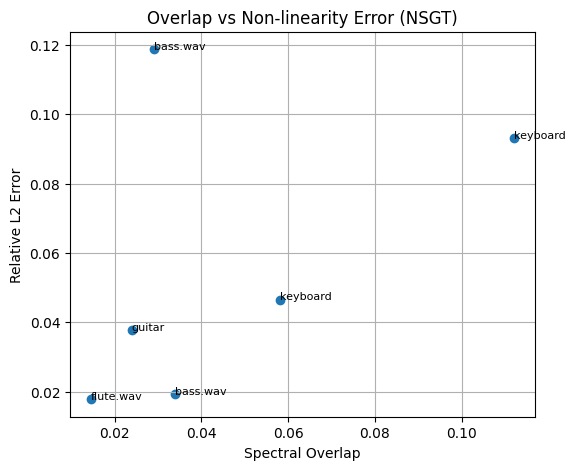

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(df["overlap"], df["relative_l2"])

for i, row in df.iterrows():
    plt.text(row["overlap"], row["relative_l2"], row["file_x"].split("_")[1], fontsize=8)

plt.xlabel("Spectral Overlap")
plt.ylabel("Relative L2 Error")
plt.title("Overlap vs Non-linearity Error (NSGT)")
plt.grid(True)
plt.show()

In [19]:
df.describe()

,l2,relative_l2,mae,overlap
count,6.000000,6.000000,6.000000,6.000000
mean,27.481410,0.055538,0.005475,0.045238
std,17.443197,0.041297,0.002963,0.035831
min,12.236917,0.017838,0.001957,0.014555
25%,13.470069,0.023952,0.003707,0.025186
50%,24.233893,0.042131,0.004681,0.031412
75%,35.195029,0.081424,0.007553,0.052015
max,55.452888,0.118713,0.009634,0.112056


In [20]:
print("Mean relative L2:", df["relative_l2"].mean())
print("Std relative L2:", df["relative_l2"].std())

Mean relative L2: 0.0555377205212911
Std relative L2: 0.04129681084725658
